# 04. Unsupervised: isolation forest

The first real model. It never sees the labels. It looks at the 16 peer-adjusted features and
asks one question of every provider: **how easy are you to separate from everyone else?**
Providers that are easy to isolate get a high anomaly score.

## Why start without labels

Two reasons, and both come up in interviews.

**Sixty-eight labels is barely enough to learn from.** A supervised model trained on 68
positives will memorize their quirks and call it a pattern. An unsupervised model cannot
overfit to labels it never saw.

**Fraud that looks nothing like past fraud is invisible to a supervised model.** It learns
"what did the caught providers look like?" A new scheme, billing in a way nobody has been
excluded for yet, scores low by construction. The unsupervised model has no such blind spot.
It flags anything unusual, whether or not it resembles history.

The cost is that "unusual" and "fraudulent" are not the same thing. Most anomalies are honest:
rare specialties, unusual practice models, data quirks. The labels come back in at the end,
not to train, but to **measure**: does the anomaly ranking put known positives near the top
more often than chance? That is what notebook 03's metrics are for.

## How an isolation forest works

Take the 1.3M providers as points in 16-dimensional space. Pick a feature at random, pick a
split value at random between that feature's min and max, and divide the points in two.
Repeat on each half. Keep going until every point is alone in its own box.

A provider in the dense middle of the crowd takes many splits to isolate, because every random
cut leaves it with thousands of neighbors. A provider far from everyone else gets cut off in
two or three splits. **The number of splits to isolate a point is its path length**, and short
paths mean anomalies.

One random tree is noisy, so build a few hundred on random subsamples and average the path
lengths. The averaged, normalized path length is the anomaly score. That is the whole
algorithm. No distances, no density estimates, no assumptions about the shape of normal.
It scales linearly and handles 1.3M rows without complaint.

## 0. Setup

**What this cell does:** imports, opens the database (read-write this time, because the
scores get saved at the end), and loads the metric functions from `src/metrics.py`.

In [1]:
import sys, time
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn import metrics as skm

PROJECT = "C:/Users/palla/OneDrive/Documents/Coding Projects/Medicare Fraud ML"
sys.path.insert(0, f"{PROJECT}/src")
import metrics as M

con = duckdb.connect(f"{PROJECT}/database/medicare_fraud.duckdb")
con.execute("SET enable_progress_bar = false")

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
SEED = 42

## 1. Load the feature matrix

**What this cell does:** pulls every provider (labeled or not, since this model does not use
labels) with the 16 z-score columns. The z-scores are the inputs, not the raw features,
because the model should find providers who are unusual **for their specialty**, not
providers in unusual specialties.

**Missing values.** Scikit-learn's isolation forest does not accept NaN. The service-derived
z-scores are missing for ~89K providers with no service rows, and `z_em_high_share` is missing
for ~785K who bill no office visits. Two things are done:

1. Fill missing z-scores with 0, meaning "no evidence either way, treat as peer-typical."
2. Add one indicator column, `has_em`, so the model can still tell "bills office visits"
   from "does not." Without it, the fill would silently make every surgeon look like an
   average office-visit biller.

`label` is loaded too, but only for the evaluation at the end. The model never sees it.

In [2]:
FEATURES = [
    "srvcs_per_bene", "pymt_per_bene", "chrg_to_alowd", "drug_pymt_share",
    "risk_score", "pymt_per_bene_per_risk", "pct_under65", "pct_dual", "avg_age",
    "n_distinct_codes", "tot_benes",
    "sameday_repeat_ratio", "em_high_share", "top_code_pymt_share", "facility_share",
    "n_service_rows",
]
Z_COLS = [f"z_{f}" for f in FEATURES]

df = q(f"""
SELECT npi, provider_type, state, label, max_abs_z,
       (em_high_share IS NOT NULL)::INT AS has_em,
       {", ".join(Z_COLS)}
FROM provider_features
""")

X = df[Z_COLS + ["has_em"]].fillna(0.0).to_numpy(dtype=np.float32)
print(f"{X.shape[0]:,} providers x {X.shape[1]} inputs")
print(f"labeled: {df['label'].notna().sum():,}   positives: {int((df['label'] == 1).sum())}")

1,296,739 providers x 17 inputs
labeled: 1,296,658   positives: 68


## 2. Fit

**What this cell does:** fits an isolation forest on all 1.3M providers and turns its output
into a score where **higher means more anomalous**.

The settings, and why:

- `n_estimators=300`: number of random trees. More trees means a steadier average. Three
  hundred is plenty; the score barely changes past a hundred.
- `max_samples=1024`: each tree is built on a random sample of 1,024 providers, not all
  1.3M. This is a feature of the algorithm, not a shortcut. Small samples make anomalies
  stand out more sharply, and the original paper recommends 256. Going a little higher
  helps when there are many features.
- `contamination="auto"`: this only affects the built-in yes/no `predict()` cutoff, which is
  never used here. Rankings come from `score_samples()`, which does not depend on it.
- `random_state=SEED`: so the run is reproducible.

Scikit-learn's `score_samples()` returns a number where **lower means more anomalous**, which
is backwards from every metric in this project. It is negated so the rest of the notebook
can say "higher is worse."

In [3]:
t0 = time.time()
iso = IsolationForest(
    n_estimators=300,
    max_samples=1024,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X)
df["iforest_score"] = -iso.score_samples(X)
print(f"fit + score in {time.time() - t0:.0f}s")
df["iforest_score"].describe().round(3)

fit + score in 20s


count    1296739.000
mean           0.352
std            0.038
min            0.316
25%            0.330
50%            0.341
75%            0.360
max            0.766
Name: iforest_score, dtype: float64

## 3. Score it against the labels

Now the labels come in, as a measuring stick only.

**What this cell does:** restricts to the labeled providers, runs the standard metric report
from notebook 03, and puts it next to the best rule-based baseline (`max_abs_z`) so the
comparison is side by side.

**What to look for:** ROC AUC above 0.60 and, more importantly, anything at all in the top
1,000. The baseline had zero there.

In [4]:
lab = df[df["label"].notna()].copy()
y = lab["label"].to_numpy(dtype=int)

report = pd.DataFrame({
    "isolation_forest": M.summarize(lab["iforest_score"].to_numpy(), y),
    "baseline_max_abs_z": M.summarize(lab["max_abs_z"].fillna(0).to_numpy(), y),
})
report.loc["base_rate"] = y.mean()
report.round(5)

,isolation_forest,baseline_max_abs_z
roc_auc,0.62922,0.60374
avg_precision,0.00011,0.00012
precision@100,0.00000,0.00000
recall@100,0.00000,0.00000
precision@1000,0.00000,0.00000
recall@1000,0.00000,0.00000
precision@10000,0.00020,0.00040
recall@10000,0.02941,0.05882
base_rate,0.00005,0.00005


## 4. Where do the 68 positives land?

A single precision@k number hides the shape. Some positives might be near the very top while
others are buried. **What this cell does:** computes each known positive's percentile rank
under the isolation forest score (100 = most anomalous of all 1.3M) and shows the distribution.

**How to read it:** if the model were random, the positives' percentiles would be spread
evenly from 0 to 100 with a median near 50. A median well above 50 means the model pushes
known fraud toward the top. The count above 99 is how many would surface in a top-1% review.

median percentile of positives : 67.6   (random would be ~50)
positives above 90th percentile: 16 of 68
positives above 99th percentile: 3 of 68
positives below 50th percentile: 21 of 68


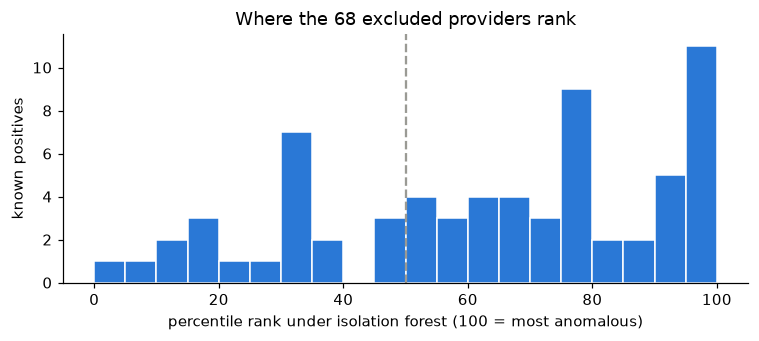

In [5]:
lab["pct_rank"] = lab["iforest_score"].rank(pct=True) * 100
pos = lab[lab["label"] == 1]

print(f"median percentile of positives : {pos['pct_rank'].median():.1f}   (random would be ~50)")
print(f"positives above 90th percentile: {(pos['pct_rank'] > 90).sum()} of {len(pos)}")
print(f"positives above 99th percentile: {(pos['pct_rank'] > 99).sum()} of {len(pos)}")
print(f"positives below 50th percentile: {(pos['pct_rank'] < 50).sum()} of {len(pos)}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(pos["pct_rank"], bins=20, range=(0, 100), color=BLUE, edgecolor="white")
ax.axvline(50, color=GRAY, ls="--", lw=1.5)
ax.set(xlabel="percentile rank under isolation forest (100 = most anomalous)",
       ylabel="known positives", title="Where the 68 excluded providers rank")
plt.tight_layout(); plt.show()

## 5. Both curves, model against baseline

**What this cell does:** draws ROC and PR for the isolation forest and the `max_abs_z`
baseline on the same axes, with the random reference in gray. The PR panel is the one that
matters; the ROC panel will make both look similar because ROC cannot see the base rate.

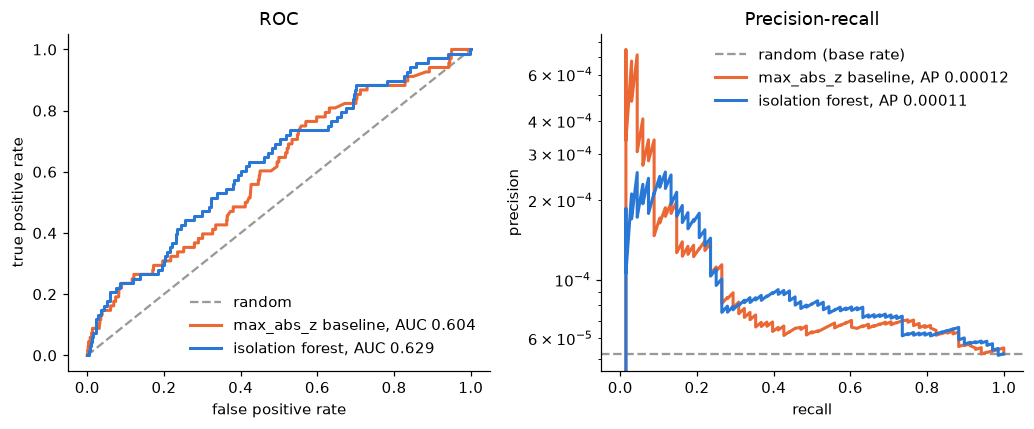

In [6]:
s_iso = lab["iforest_score"].to_numpy()
s_base = lab["max_abs_z"].fillna(0).to_numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
ax1.plot([0, 1], [0, 1], color=GRAY, lw=1.5, ls="--", label="random")
for s, name, col in [(s_base, "max_abs_z baseline", ORANGE), (s_iso, "isolation forest", BLUE)]:
    fpr, tpr, _ = skm.roc_curve(y, s)
    ax1.plot(fpr, tpr, color=col, lw=2, label=f"{name}, AUC {M.auc_pairs(s, y):.3f}")
ax1.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
ax1.legend(frameon=False, loc="lower right")

ax2.axhline(y.mean(), color=GRAY, lw=1.5, ls="--", label="random (base rate)")
for s, name, col in [(s_base, "max_abs_z baseline", ORANGE), (s_iso, "isolation forest", BLUE)]:
    p, r, _ = skm.precision_recall_curve(y, s)
    ax2.plot(r[:-1], p[:-1], color=col, lw=2, label=f"{name}, AP {M.average_precision(s, y):.5f}")
ax2.set(xlabel="recall", ylabel="precision", title="Precision-recall", yscale="log")
ax2.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

The PR panel uses a **log scale** on the y-axis. On a linear scale everything below 0.01
collapses onto the x-axis and the two curves are indistinguishable. Log spreads out the range
that matters: the base rate is 0.00005, and a model reaching 0.001 at low recall is twenty
times better than random even though both look like zero on a linear axis.

## 6. What does the top of the ranking look like?

The metrics say how many known positives surfaced. They do not say what the model is actually
reacting to. **What this cell does:** shows the 15 most anomalous providers with their
specialty and the three z-scores that pushed them there.

**Why:** this is the check an investigator would do first. If the top of the list is all
one specialty, or all one feature, the model has found a data quirk rather than a fraud
pattern. If it is a mix of specialties flagged for different reasons, it is doing its job.

In [7]:
top = df.nlargest(15, "iforest_score").copy()

def top_drivers(row, n=3):
    zs = row[Z_COLS].astype(float).abs().sort_values(ascending=False)
    return ", ".join(f"{c[2:]}={row[c]:+.1f}" for c in zs.index[:n])

top["top_drivers"] = top.apply(top_drivers, axis=1)
top[["npi", "provider_type", "state", "label", "iforest_score", "top_drivers"]].reset_index(drop=True)

,npi,provider_type,state,label,iforest_score,top_drivers
0,1417915653,Pharmacy,PA,0,0.765711,"srvcs_per_bene=+95256.2, pymt_per_bene=+2936.2..."
1,1922019561,Pharmacy,MI,0,0.757842,"srvcs_per_bene=+174185.2, pymt_per_bene=+8355...."
2,1356746267,Pharmacy,CA,0,0.756923,"srvcs_per_bene=+213608.4, pymt_per_bene=+7842...."
3,1659355170,Infectious Disease,VA,0,0.756533,"srvcs_per_bene=+369.3, pymt_per_bene_per_risk=..."
4,1013998921,Pharmacy,CA,0,0.753530,"srvcs_per_bene=+275294.7, pymt_per_bene=+7144...."
5,1548385594,Emergency Medicine,NV,0,0.752644,"srvcs_per_bene=+774.0, pymt_per_bene_per_risk=..."
6,1992932214,Hospitalist,CA,0,0.752261,"srvcs_per_bene=+735.2, pymt_per_bene_per_risk=..."
7,1750533816,Pharmacy,TN,0,0.752226,"pymt_per_bene=+7737.2, srvcs_per_bene=+7038.2,..."
8,1043382302,Pharmacy,PA,0,0.747868,"srvcs_per_bene=+283434.6, pymt_per_bene=+5267...."
9,1437492238,Diagnostic Radiology,MD,0,0.747319,"pymt_per_bene=+3571.9, pymt_per_bene_per_risk=..."


**What this cell does:** counts which specialties appear most in the top 1,000, next to their
share of the whole population.

**Why:** a specialty that is 2% of providers but 30% of the top 1,000 is being flagged as a
group. That usually means the peer adjustment did not fully work for that group, or the
specialty genuinely has a wider spread than the z-scores captured. Either way it is worth
knowing before handing the list to anyone.

In [8]:
top1k = df.nlargest(1000, "iforest_score")
mix = (top1k["provider_type"].value_counts(normalize=True).rename("share_of_top_1000").to_frame()
       .join(df["provider_type"].value_counts(normalize=True).rename("share_of_all")))
mix["over_representation"] = (mix["share_of_top_1000"] / mix["share_of_all"]).round(1)
mix.head(12).round(3)

,share_of_top_1000,share_of_all,over_representation
provider_type,,,
Nurse Practitioner,0.444,0.157,2.8
Medical Oncology,0.118,0.003,40.2
Physician Assistant,0.060,0.087,0.7
Emergency Medicine,0.054,0.039,1.4
Pharmacy,0.042,0.002,18.5
Internal Medicine,0.030,0.072,0.4
Hematology-Oncology,0.025,0.007,3.5
Diagnostic Radiology,0.017,0.025,0.7
Podiatry,0.017,0.012,1.4


## 7. Is it the tails? Testing a fix

The top of the ranking is dominated by pharmacies with z-scores in the tens of thousands.
That is a real data quirk: pharmacies bill Part B drugs in dose units, and most pharmacies
bill very few, so the peer group's spread (MAD) is tiny and a handful of infusion or
vaccination pharmacies get astronomical z-scores. An isolation forest picks split points
uniformly between a feature's min and max, so one provider at 760,000 makes everyone below
1,000 look identical.

The obvious fix is to squash the tails before fitting. **What this cell does:** refits the
forest with every z-score clipped to the range -10 to +10 and reports the same metrics.

**What to look for:** if clipping helps, the tails were the problem. If the numbers barely
move, the model is finding real anomalies and they simply are not the known fraud.

In [9]:
X_clip = df[Z_COLS].fillna(0.0).clip(-10, 10).assign(has_em=df["has_em"]).to_numpy(dtype=np.float32)

iso_clip = IsolationForest(n_estimators=300, max_samples=1024, random_state=SEED, n_jobs=-1).fit(X_clip)
s_clip = -iso_clip.score_samples(X_clip)

report["isolation_forest_clipped"] = pd.Series(M.summarize(s_clip[df["label"].notna().to_numpy()], y))
report.loc["base_rate", "isolation_forest_clipped"] = y.mean()
report.round(5)

,isolation_forest,baseline_max_abs_z,isolation_forest_clipped
roc_auc,0.62922,0.60374,0.62020
avg_precision,0.00011,0.00012,0.00010
precision@100,0.00000,0.00000,0.00000
recall@100,0.00000,0.00000,0.00000
precision@1000,0.00000,0.00000,0.00000
recall@1000,0.00000,0.00000,0.00000
precision@10000,0.00020,0.00040,0.00020
recall@10000,0.02941,0.05882,0.02941
base_rate,0.00005,0.00005,0.00005


The clipped version lands within noise of the original on every metric. Rank-transforming
and log-transforming the inputs (tried outside this notebook) do the same. The tails are not
the problem. The model is doing exactly what it was built to do, finding the most unusual
providers, and the most unusual providers are overwhelmingly honest.

## 8. Save the scores

**What this cell does:** writes the isolation forest score for all 1.3M providers to a table
called `scores_iforest`. The supervised notebook will compare against it, and the retrieval
notebook will use it to pick providers to explain.

**Why a table and not a CSV:** same reason as the labels. One copy, in the database, that
every later notebook reads.

In [10]:
con.execute("DROP TABLE IF EXISTS scores_iforest")
con.execute("CREATE TABLE scores_iforest AS SELECT npi, iforest_score FROM df")
q("SELECT count(*) AS n, round(min(iforest_score), 3) AS mn, round(max(iforest_score), 3) AS mx FROM scores_iforest")

,n,mn,mx
0,1296739,0.316,0.766


## 9. What to carry forward

**The forest ranks better than the rule overall and no better at the top.** ROC AUC moved
from 0.60 to 0.63. Median percentile of the known positives is about 68, so the model does
push them upward: two thirds of them sit in the more-anomalous half. But precision at 1,000
is still zero, and at 10,000 the forest catches two of the 68 where the single-column rule
caught four. Nothing changes that: not clipping, not rank transforms, not smaller subsamples.

**Anomalous is not fraudulent.** That is the sentence to remember from this notebook. The most
unusual providers in Medicare are infusion pharmacies, oncologists with heavy drug billing,
and nurse practitioners in unusual practice models. They are unusual because their work is
unusual. The known fraud sits a modest half-spread from normal on several features at once,
and "modest on several" never wins an anomaly contest against "enormous on one."

**Why this is still worth having.** Unsupervised scoring finds novelty, and novelty is
exactly what a model trained on past exclusions cannot see. In a real program-integrity shop
the anomaly list is not an investigation queue. It is a watch list: providers whose billing
changed shape, new entrants who look like nothing else, patterns worth a second look when a
tip comes in. The supervised model is where precision comes from. The two are complementary.

**The honest framing for an interview:** "I built an isolation forest on peer-adjusted billing
features. It ranked known-fraud providers above the median but put none in the top 1,000,
and the top of its list was dominated by legitimate high-volume drug billers. That taught me
that anomaly detection alone does not find this kind of fraud, and it pushed me toward a
supervised model with peer-group features where the signal actually lives."

Being able to say what did not work, and why, is worth more than a good number.

In [11]:
con.close()